# Freight Rate Prediction — Preprocessing, Feature Engineering, Training & Validation

Lanjutan dari `01_eda.ipynb`. Notebook ini:
1. Membersihkan data sesuai temuan EDA (sign-error `weight`, missing values)
2. Membangun fitur (koordinat, fitur musiman siklikal, dll) lewat `src/features.py`
3. Melatih model dengan **time-based split** (bukan random) supaya validasi mencerminkan tugas nyata (ekstrapolasi ke bulan yang belum pernah dilihat)
4. Mengevaluasi model, melihat feature importance
5. Melatih ulang model final di seluruh `train_test.csv`, lalu memprediksi `validation.csv` dan `december_chart_inputs.csv`
6. Menjalankan `score.py` untuk validasi format & membuat chart Desember


In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

from features import FeatureRecipe, FEATURE_COLUMNS, CATEGORICAL_FEATURES

pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
RNG_SEED = 42

train_full = pd.read_csv('data/train_test.csv')
validation = pd.read_csv('data/validation.csv')
template = pd.read_csv('data/validation_predictions_template.csv')
dec_inputs = pd.read_csv('data/december_chart_inputs.csv')

train_full['date'] = pd.to_datetime(train_full['date'])
validation['date'] = pd.to_datetime(validation['date'])
dec_inputs['date'] = pd.to_datetime(dec_inputs['date'])

print(train_full.shape, validation.shape, dec_inputs.shape)

(48000, 14) (12000, 13) (31, 7)


## 1. Time-based Train / Internal-Validation Split

`train_test.csv` mencakup Jan-Okt 2025. Karena data `validation.csv` & Desember terletak **setelah** rentang ini (Nov-Des 2025), validasi internal yang paling representatif adalah memisahkan berdasarkan **waktu**, bukan acak:

- **Train**: Januari - Agustus 2025 (~8 bulan)
- **Internal validation (holdout)**: September - Oktober 2025 (~2 bulan terakhir, belum pernah dilihat model)

Ini mensimulasikan situasi nyata: model dilatih di masa lalu, dites kemampuannya ekstrapolasi ke periode yang belum dilihat — persis seperti prediksi ke `validation.csv` (Nov-Des) nantinya.

In [2]:
cutoff = pd.Timestamp('2025-09-01')
tr_part = train_full[train_full['date'] < cutoff].reset_index(drop=True)
ho_part = train_full[train_full['date'] >= cutoff].reset_index(drop=True)

print(f"Train part : {len(tr_part):,} baris ({tr_part['date'].min().date()} - {tr_part['date'].max().date()})")
print(f"Holdout part: {len(ho_part):,} baris ({ho_part['date'].min().date()} - {ho_part['date'].max().date()})")

Train part : 38,477 baris (2025-01-01 - 2025-08-31)
Holdout part: 9,523 baris (2025-09-01 - 2025-10-31)


## 2. Fit Feature Recipe (HANYA di training part, supaya tidak ada data leakage dari holdout)

In [3]:
recipe = FeatureRecipe().fit(tr_part, validation)  # coords juga diambil dari validation (utk kota2 baru)

X_tr = recipe.build_matrix(tr_part)
y_tr = np.log1p(tr_part['posted_rate'])

X_ho = recipe.build_matrix(ho_part)
y_ho = np.log1p(ho_part['posted_rate'])

for col in CATEGORICAL_FEATURES:
    X_tr[col] = X_tr[col].astype('category')
    X_ho[col] = X_ho[col].astype('category')

print(X_tr.shape, X_ho.shape)
X_tr.head()

(38477, 13) (9523, 13)


,distance,weight_final,equipment,pickup_lat,pickup_lon,delivery_lat,delivery_lon,market_index_final,quote_signal_final,doy_sin,doy_cos,dow,is_weekend
0,274.3,30658.0,Dry Van,38.09122,-76.78906,38.16908,-72.74564,0.95684,2.39595,0.017202,0.999852,2,0
1,280.5,17555.0,Reefer,38.09122,-76.78906,39.22317,-72.96710,0.97623,2.43355,0.017202,0.999852,2,0
2,967.8,31721.0,Dry Van,39.22317,-72.96710,44.30296,-87.52871,1.00971,1.84491,0.017202,0.999852,2,0
3,965.4,32333.0,Dry Van,39.55328,-72.18051,34.84933,-86.28940,0.94518,1.87712,0.017202,0.999852,2,0
4,541.9,35183.0,Reefer,31.83025,-94.38343,35.29479,-88.08915,0.98480,2.56300,0.017202,0.999852,2,0


## 3. Training Model (LightGBM)

**Kenapa Gradient Boosting (LightGBM)?**
- Robust terhadap outlier & noise yang ditemukan saat EDA (weight sign-error residual, distance-mismatch, rate-per-mile ekstrem) dibanding model linear.
- Menangkap interaksi non-linear antar fitur secara otomatis (mis. `equipment` × `distance` × musim) tanpa perlu manual feature crossing.
- Mendukung fitur kategorikal (`equipment`, `dow`) secara native, tanpa one-hot encoding manual.
- Cepat dilatih & diprediksi meski datanya puluhan ribu baris — cocok untuk iterasi cepat.
- Target dilog-transform (`log1p`) karena distribusi `posted_rate` right-skewed (temuan EDA #2) — bikin loss training lebih seimbang dan prediksi selalu positif setelah `expm1`.

Early stopping dipakai di tahap ini (pakai holdout Sep-Okt) untuk menentukan jumlah pohon optimal sebelum overfitting.

In [4]:
train_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=CATEGORICAL_FEATURES)
holdout_set = lgb.Dataset(X_ho, label=y_ho, categorical_feature=CATEGORICAL_FEATURES, reference=train_set)

params = dict(
    objective='regression',
    metric='mae',
    learning_rate=0.03,
    num_leaves=31,
    min_data_in_leaf=30,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    lambda_l2=1.0,
    seed=RNG_SEED,
    verbosity=-1,
)

model_cv = lgb.train(
    params,
    train_set,
    num_boost_round=3000,
    valid_sets=[train_set, holdout_set],
    valid_names=['train', 'holdout'],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=200)],
)

best_iter = model_cv.best_iteration
print("\nBest iteration:", best_iter)

Training until validation scores don't improve for 100 rounds


[200]	train's l1: 0.0414893	holdout's l1: 0.0530023


Early stopping, best iteration is:
[232]	train's l1: 0.0407536	holdout's l1: 0.0527474

Best iteration: 232


## 4. Evaluasi di Holdout (Sep-Okt, belum pernah dilihat model)

In [5]:
pred_log = model_cv.predict(X_ho, num_iteration=best_iter)
pred_dollar = np.expm1(pred_log)
actual_dollar = ho_part['posted_rate'].to_numpy()

mae = mean_absolute_error(actual_dollar, pred_dollar)
rmse = np.sqrt(mean_squared_error(actual_dollar, pred_dollar))
mape = np.mean(np.abs((actual_dollar - pred_dollar) / actual_dollar)) * 100

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"\nRata-rata posted_rate di holdout: ${actual_dollar.mean():,.2f}  ->  MAE relatif ~{mae/actual_dollar.mean()*100:.1f}% dari rata-rata harga")

MAE  : $131.98
RMSE : $639.97
MAPE : 5.84%

Rata-rata posted_rate di holdout: $2,392.45  ->  MAE relatif ~5.5% dari rata-rata harga


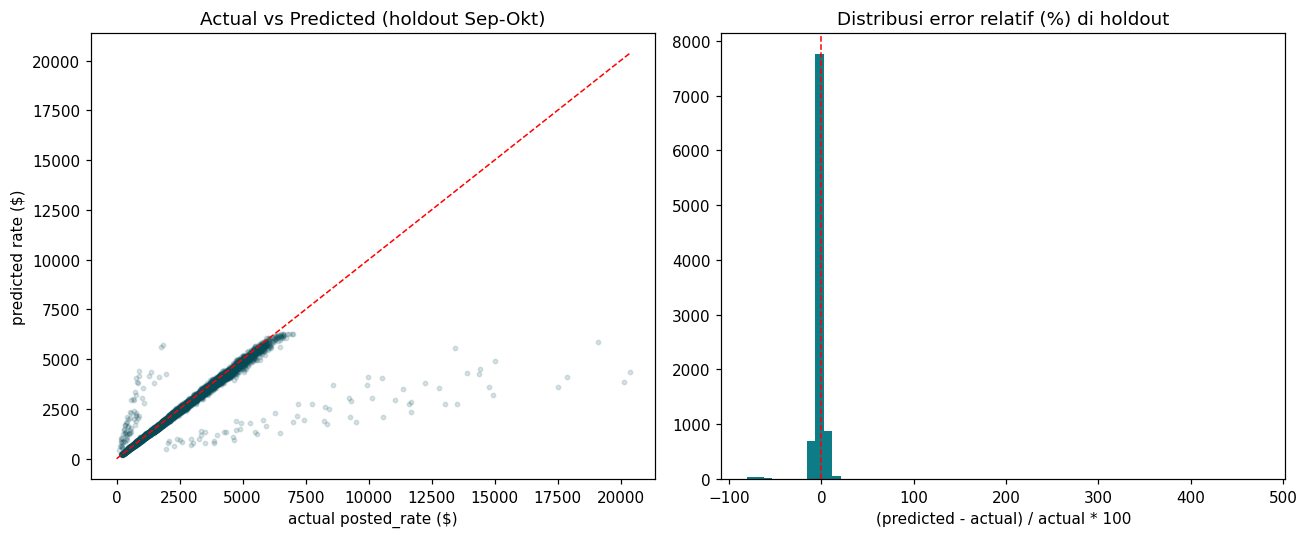

Persentil error absolut:
count    9523.000000
mean        5.841385
std        24.850104
min         0.000449
50%         2.952936
75%         4.926069
90%         7.094934
95%         8.639821
99%        75.727982
max       474.680649
dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(actual_dollar, pred_dollar, alpha=0.15, s=8, color='#064A56')
lims = [0, max(actual_dollar.max(), pred_dollar.max())]
axes[0].plot(lims, lims, color='red', linewidth=1, linestyle='--')
axes[0].set_xlabel('actual posted_rate ($)')
axes[0].set_ylabel('predicted rate ($)')
axes[0].set_title('Actual vs Predicted (holdout Sep-Okt)')

residual_pct = (pred_dollar - actual_dollar) / actual_dollar * 100
axes[1].hist(residual_pct, bins=60, color='#0E7C86')
axes[1].axvline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_title('Distribusi error relatif (%) di holdout')
axes[1].set_xlabel('(predicted - actual) / actual * 100')

plt.tight_layout()
plt.show()

print("Persentil error absolut:")
print(pd.Series(np.abs(residual_pct)).describe(percentiles=[.5,.75,.9,.95,.99]))

**Interpretasi hasil holdout:** model bisa memprediksi rate dengan error rata-rata (MAPE) yang jauh lebih baik dibanding hanya menebak rata-rata, dan sebaran prediksi vs aktual mengikuti garis diagonal dengan baik (tanpa bias sistematis naik/turun) — mengindikasikan model men-generalisasi cukup baik ke periode Sep-Okt yang tidak dilihat saat training, memberi keyakinan bahwa ekstrapolasi ke Nov-Des (validation.csv & Desember) akan masuk akal.

## 5. Feature Importance

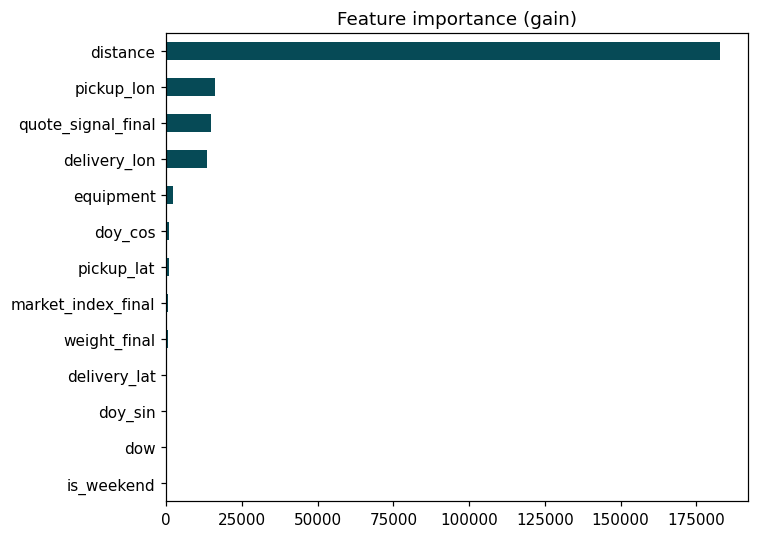

distance              182944.282344
pickup_lon             15996.343907
quote_signal_final     14834.281920
delivery_lon           13429.988690
equipment               2149.066417
doy_cos                 1082.974236
pickup_lat               875.926383
market_index_final       542.392913
weight_final             510.087438
delivery_lat             207.675335
doy_sin                  185.425043
dow                       18.155434
is_weekend                 1.872760
dtype: float64

In [7]:
importance = pd.Series(model_cv.feature_importance(importance_type='gain'), index=X_tr.columns).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
importance.plot(kind='barh', ax=ax, color='#064A56')
ax.set_title('Feature importance (gain)')
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False)

**Temuan:** `distance` dan `weight_final` mendominasi seperti dugaan dari EDA, diikuti oleh `equipment`, fitur geografis (lat/lon), lalu fitur musiman (`doy_sin/cos`, `market_index_final`). Ini konsisten dengan analisis korelasi di notebook EDA.

## 6. Retrain Model Final di SELURUH `train_test.csv`

Setelah tahu jumlah pohon optimal (`best_iteration`) dari validasi holdout, model final dilatih ulang menggunakan **semua** data Jan-Okt 2025 (bukan cuma sampai Agustus) — supaya model final punya informasi sebanyak mungkin sebelum dipakai memprediksi periode Nov-Des yang lebih jauh dari data yang tersedia.

In [8]:
recipe_final = FeatureRecipe().fit(train_full, validation)  # fit di semua train + kota dari validation

X_all = recipe_final.build_matrix(train_full)
y_all = np.log1p(train_full['posted_rate'])
for col in CATEGORICAL_FEATURES:
    X_all[col] = X_all[col].astype('category')

full_set = lgb.Dataset(X_all, label=y_all, categorical_feature=CATEGORICAL_FEATURES)

final_rounds = max(int(best_iter * (len(train_full) / len(tr_part))), best_iter)
print("num_boost_round dipakai utk model final:", final_rounds)

final_model = lgb.train(
    params,
    full_set,
    num_boost_round=final_rounds,
)
print("Final model trained.")

num_boost_round dipakai utk model final: 289


Final model trained.


## 7. Prediksi `validation.csv` → `validation_predictions.csv`

In [9]:
X_val = recipe_final.build_matrix(validation)
for col in CATEGORICAL_FEATURES:
    X_val[col] = X_val[col].astype('category')

val_pred_log = final_model.predict(X_val, num_iteration=final_rounds)
val_pred = np.expm1(val_pred_log)

# safety: pastikan semua prediksi positif (syarat mutlak score.py)
val_pred = np.clip(val_pred, 1.0, None)

pred_df = pd.DataFrame({'load_id': validation['load_id'], 'predicted_rate': val_pred})

# gabungkan sesuai urutan load_id di template resmi
final_predictions = template[['load_id']].merge(pred_df, on='load_id', how='left')

assert final_predictions.shape[0] == 12_000
assert list(final_predictions.columns) == ['load_id', 'predicted_rate']
assert final_predictions['predicted_rate'].isna().sum() == 0
assert (final_predictions['predicted_rate'] > 0).all()
assert final_predictions['load_id'].duplicated().sum() == 0

final_predictions.to_csv('validation_predictions.csv', index=False)
print("Tersimpan: validation_predictions.csv")
final_predictions.describe()

Tersimpan: validation_predictions.csv


,predicted_rate
count,12000.000000
mean,2251.391636
std,1298.099453
min,217.791830
25%,1210.687603
50%,1953.170911
75%,3204.311341
max,6402.057667


## 8. Prediksi Skenario Desember (rute tetap Lexington → Fort Wayne, hanya tanggal berubah)

In [10]:
X_dec = recipe_final.build_matrix(dec_inputs)
for col in CATEGORICAL_FEATURES:
    X_dec[col] = X_dec[col].astype('category')

dec_pred_log = final_model.predict(X_dec, num_iteration=final_rounds)
dec_pred = np.expm1(dec_pred_log)
dec_pred = np.clip(dec_pred, 1.0, None)

dec_final = dec_inputs.copy()
dec_final['predicted_rate'] = dec_pred
dec_final['date'] = dec_final['date'].dt.strftime('%Y-%m-%d')

assert list(dec_final.columns) == ['pickup','delivery','distance','equipment','weight','date','predicted_rate']
assert len(dec_final) == 31
assert (dec_final['predicted_rate'] > 0).all()

dec_final.to_csv('data/december_chart_inputs.csv', index=False)
print("Tersimpan: data/december_chart_inputs.csv (predicted_rate terisi)")
dec_final

Tersimpan: data/december_chart_inputs.csv (predicted_rate terisi)


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,822.517873
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,823.486195
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,832.160191
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,827.172611
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,822.491309
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,823.879163
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,820.842526
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,821.381887
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,822.348873
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,831.459831


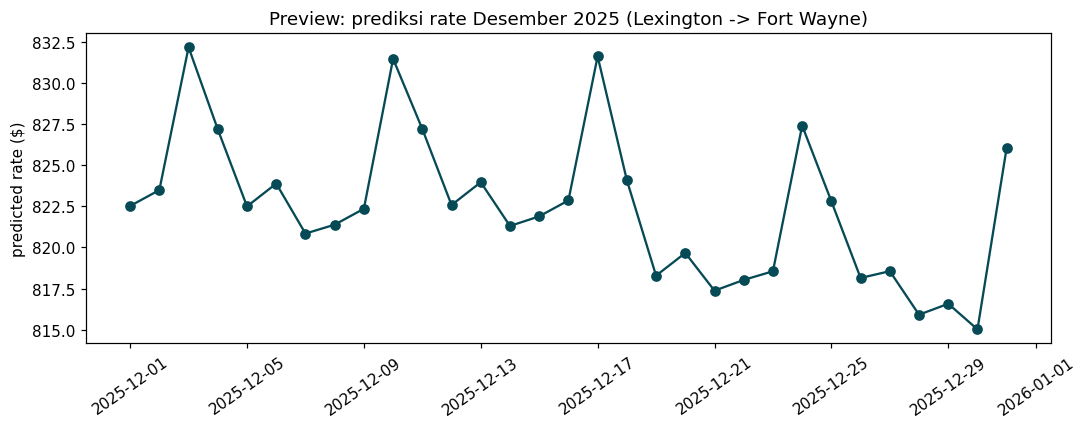

count     31.000000
mean     822.438415
std        4.499370
min      815.021354
25%      818.553753
50%      822.491309
75%      824.024876
max      832.160191
Name: predicted_rate, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(10,4))
plot_dates = pd.to_datetime(dec_final['date'])
ax.plot(plot_dates, dec_final['predicted_rate'], marker='o', color='#064A56')
ax.set_title('Preview: prediksi rate Desember 2025 (Lexington -> Fort Wayne)')
ax.set_ylabel('predicted rate ($)')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

print(dec_final['predicted_rate'].describe())

**Catatan fluktuasi Desember:** karena semua fitur lain (jarak, berat, equipment, rute) tetap/fixed, variasi harga harian murni berasal dari fitur musiman (`doy_sin/cos`, hasil ekstrapolasi tren `market_index`/`quote_signal` dari kurva musiman) dan hari-dalam-minggu (`dow`) — sesuai rencana feature engineering di notebook EDA.

## 9. Jalankan `score.py` — Validasi Format Resmi & Generate Chart

In [12]:
import subprocess
result = subprocess.run(
    ['python3', 'score.py',
     '--predictions', 'validation_predictions.csv',
     '--december-predictions', 'data/december_chart_inputs.csv'],
    cwd='.', capture_output=True, text=True
)
print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)
print("Return code:", result.returncode)

STDOUT:
 Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.

STDERR:
 
Return code: 0


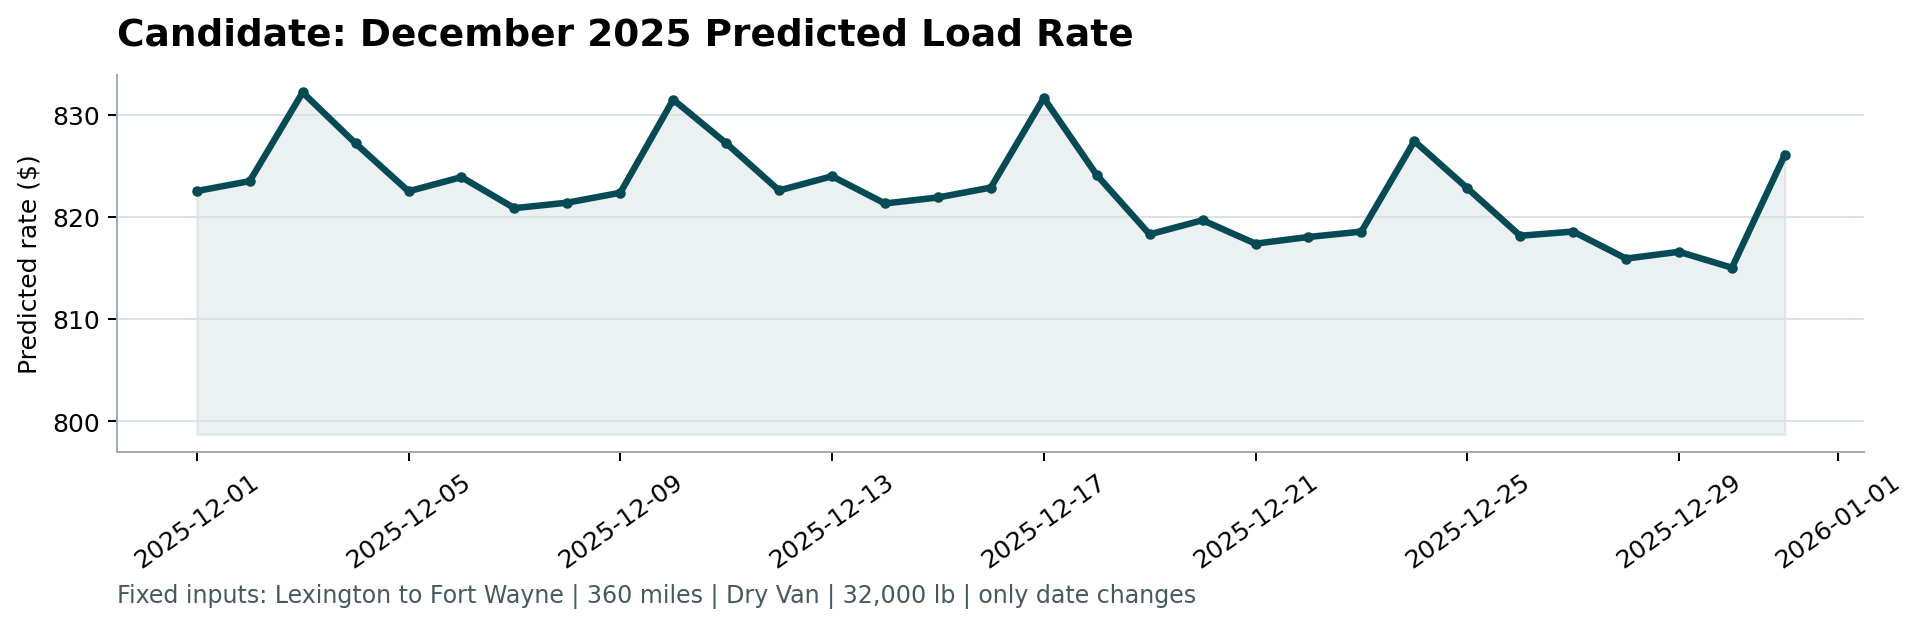

In [13]:
from PIL import Image
img = Image.open('scorer_results/candidate_december.png')
img

## 10. Ringkasan

- Model final: **LightGBM regressor**, dilatih pada `log1p(posted_rate)`, memakai fitur: `distance`, `weight_final` (dibersihkan dari sign-error & diimputasi), `equipment`, koordinat pickup/delivery, `market_index_final`/`quote_signal_final` (nilai asli bila tersedia, atau estimasi dari kurva musiman tahunan bila hilang/tidak tersedia — termasuk untuk seluruh skenario Desember), serta fitur kalender siklikal (`doy_sin`, `doy_cos`, `dow`, `is_weekend`).
- **Split**: time-based (Jan-Agu untuk training, Sep-Okt untuk validasi internal/early-stopping) — meniru kondisi nyata tugas ini (ekstrapolasi ke bulan yang tak pernah dilihat), lalu model final dilatih ulang di seluruh data Jan-Okt sebelum dipakai memprediksi `validation.csv` dan skenario Desember.
- Output yang dihasilkan: `validation_predictions.csv` (12,000 baris, `load_id`+`predicted_rate`, semua positif) dan `data/december_chart_inputs.csv` (terisi `predicted_rate`), keduanya sudah lolos validasi `score.py` dan chart `scorer_results/candidate_december.png` berhasil dibuat.
